In [ ]:
pip install matplotlib

In [ ]:
pip install pandas

In [35]:
pip install scipy

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 30.3 MB 1.8 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [15]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 294 kB 2.0 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


Loading data...


/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/377772577.py:65: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  encounters["Date"] = pd.to_datetime(encounters["Date"])



=== CONTINUITY METRICS ===
Avg Gap: 23.3
Long Gap %: 11.51
Avg Visits: 1.82


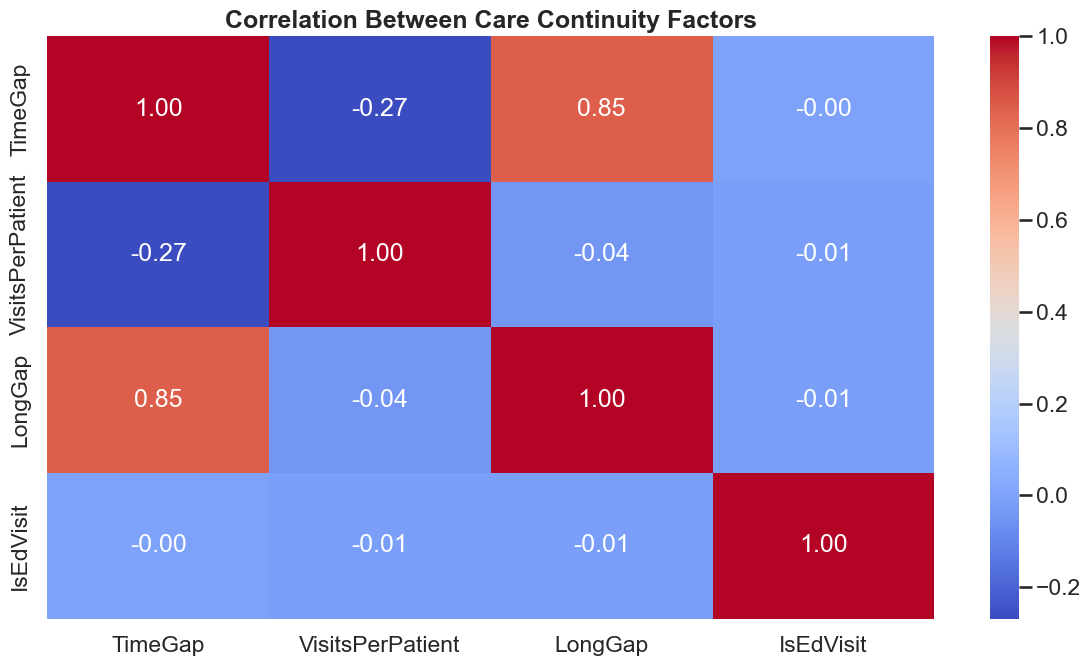

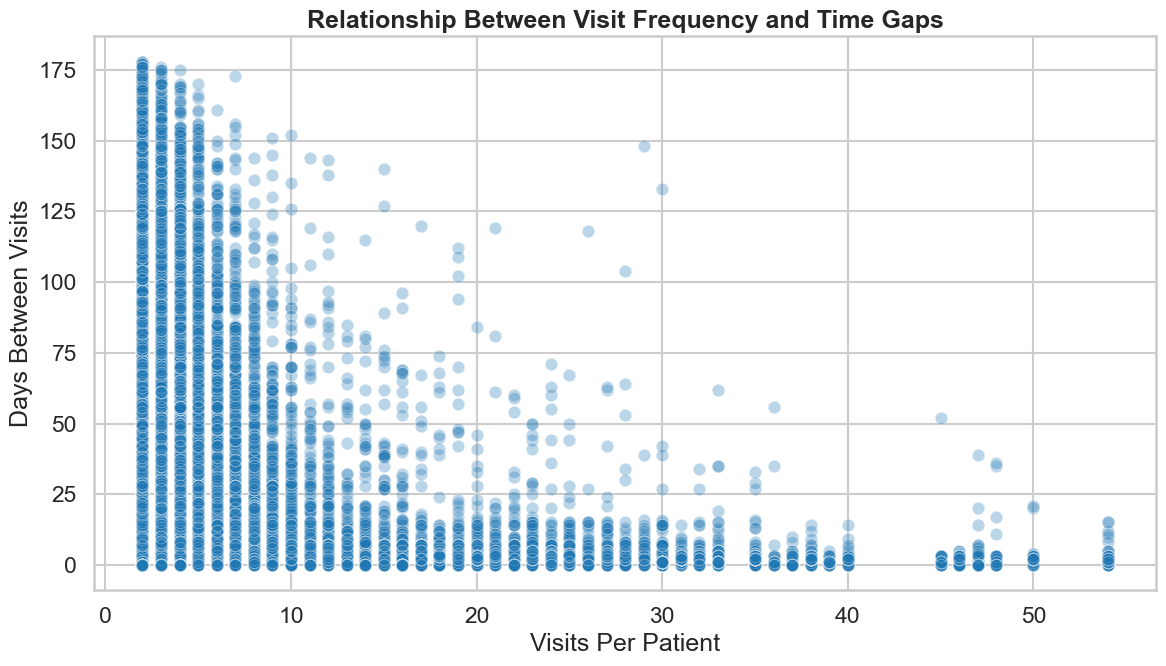

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/377772577.py:150: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


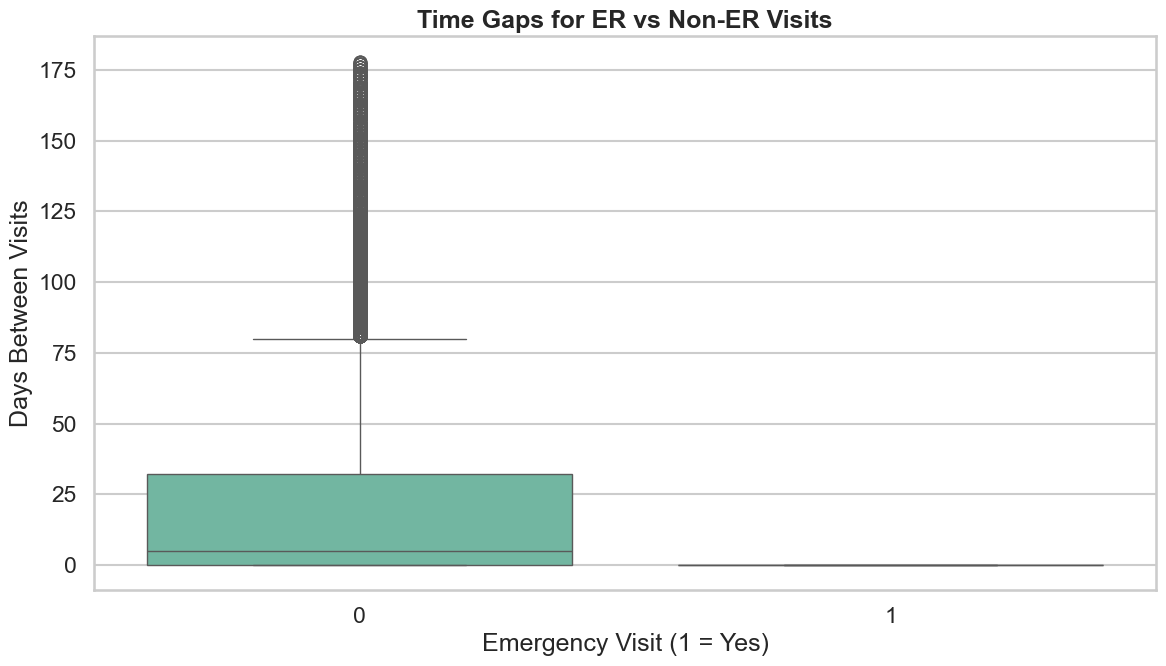

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/377772577.py:165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


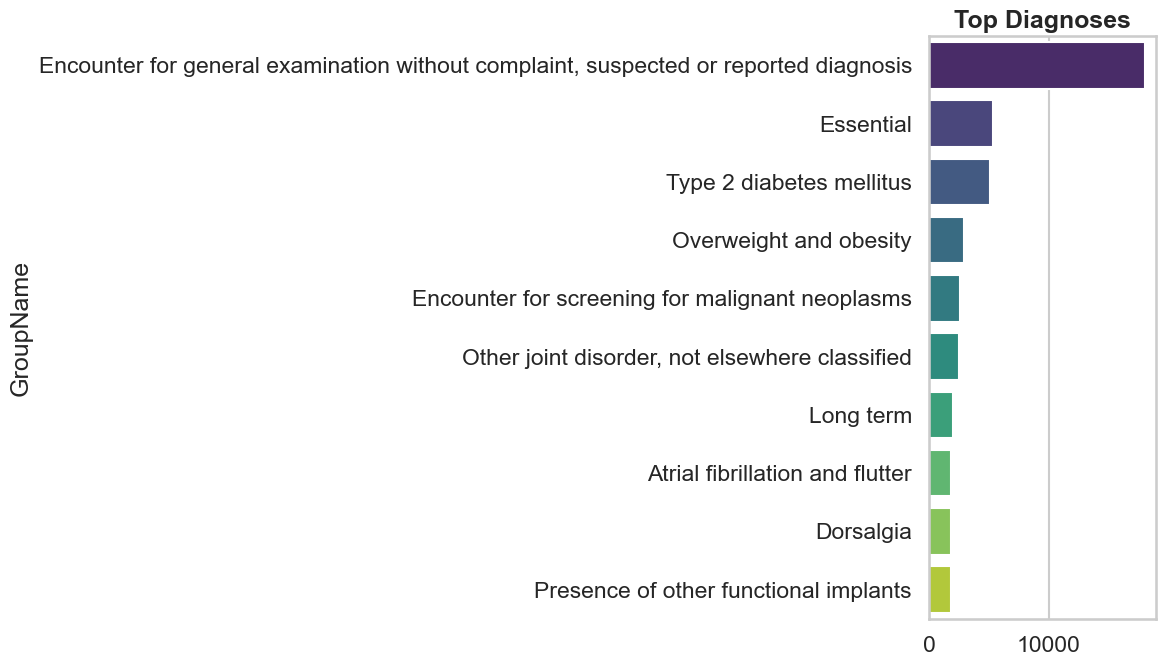


DONE 🔥


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams["figure.figsize"] = (12, 7)

print("Loading data...")

encounters = pd.read_csv("/Users/sampanackal/Documents/DATAFEST 26/encounters.csv", nrows=100000)
patients = pd.read_csv("/Users/sampanackal/Documents/DATAFEST 26/patients.csv")
diagnosis = pd.read_csv("/Users/sampanackal/Documents/DATAFEST 26/diagnosis.csv")
census = pd.read_csv("/Users/sampanackal/Documents/DATAFEST 26/tigercensuscodes.csv")

def clean(df):
    df.columns = df.columns.str.strip()
    return df

encounters = clean(encounters)
patients = clean(patients)
diagnosis = clean(diagnosis)
census = clean(census)


encounters = encounters[[
    "PatientDurableKey",
    "Date",
    "PrimaryDiagnosisKey",
    "VisitType",
    "IsEdVisit"
]]

patients = patients[[
    "DurableKey",
    "CensusBlockGroupFipsCode"
]]

diagnosis = diagnosis[[
    "DiagnosisKey",
    "GroupName"
]]

census = census[[
    "GEOID",
    "PopulationValue",
    "CENTLAT",
    "CENTLON"
]]

encounters["Date"] = pd.to_datetime(encounters["Date"])

df = encounters.merge(
    patients,
    left_on="PatientDurableKey",
    right_on="DurableKey",
    how="left"
)

df = df.merge(
    diagnosis,
    left_on="PrimaryDiagnosisKey",
    right_on="DiagnosisKey",
    how="left"
)

# FIX TYPES
df["CensusBlockGroupFipsCode"] = df["CensusBlockGroupFipsCode"].astype(str)
census["GEOID"] = census["GEOID"].astype(str)

df = df.merge(
    census,
    left_on="CensusBlockGroupFipsCode",
    right_on="GEOID",
    how="left"
)

df = df.sort_values(by=["PatientDurableKey", "Date"])

df["PrevDate"] = df.groupby("PatientDurableKey")["Date"].shift(1)
df["TimeGap"] = (df["Date"] - df["PrevDate"]).dt.days
df["LongGap"] = df["TimeGap"] > 30

visits_per_patient = df.groupby("PatientDurableKey").size()
df["VisitsPerPatient"] = df["PatientDurableKey"].map(visits_per_patient)

print("\n=== CONTINUITY METRICS ===")
print("Avg Gap:", round(df["TimeGap"].mean(), 2))
print("Long Gap %:", round(df["LongGap"].mean()*100, 2))
print("Avg Visits:", round(visits_per_patient.mean(), 2))

corr_df = df[["TimeGap", "VisitsPerPatient", "LongGap", "IsEdVisit"]].copy()
corr_df["LongGap"] = corr_df["LongGap"].astype(int)

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Between Care Continuity Factors", weight='bold')
plt.tight_layout()
plt.show()

sns.scatterplot(
    x="VisitsPerPatient",
    y="TimeGap",
    data=df,
    alpha=0.3
)
plt.title("Relationship Between Visit Frequency and Time Gaps", weight='bold')
plt.xlabel("Visits Per Patient")
plt.ylabel("Days Between Visits")
plt.tight_layout()
plt.show()

sns.boxplot(
    x="IsEdVisit",
    y="TimeGap",
    data=df,
    palette="Set2"
)
plt.title("Time Gaps for ER vs Non-ER Visits", weight='bold')
plt.xlabel("Emergency Visit (1 = Yes)")
plt.ylabel("Days Between Visits")
plt.tight_layout()
plt.show()

top_conditions = df["GroupName"].value_counts().head(10)

sns.barplot(
    x=top_conditions.values,
    y=top_conditions.index,
    palette="viridis"
)
plt.title("Top Diagnoses", weight='bold')
plt.tight_layout()
plt.show()

print("\nDONE 🔥")

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/509472875.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


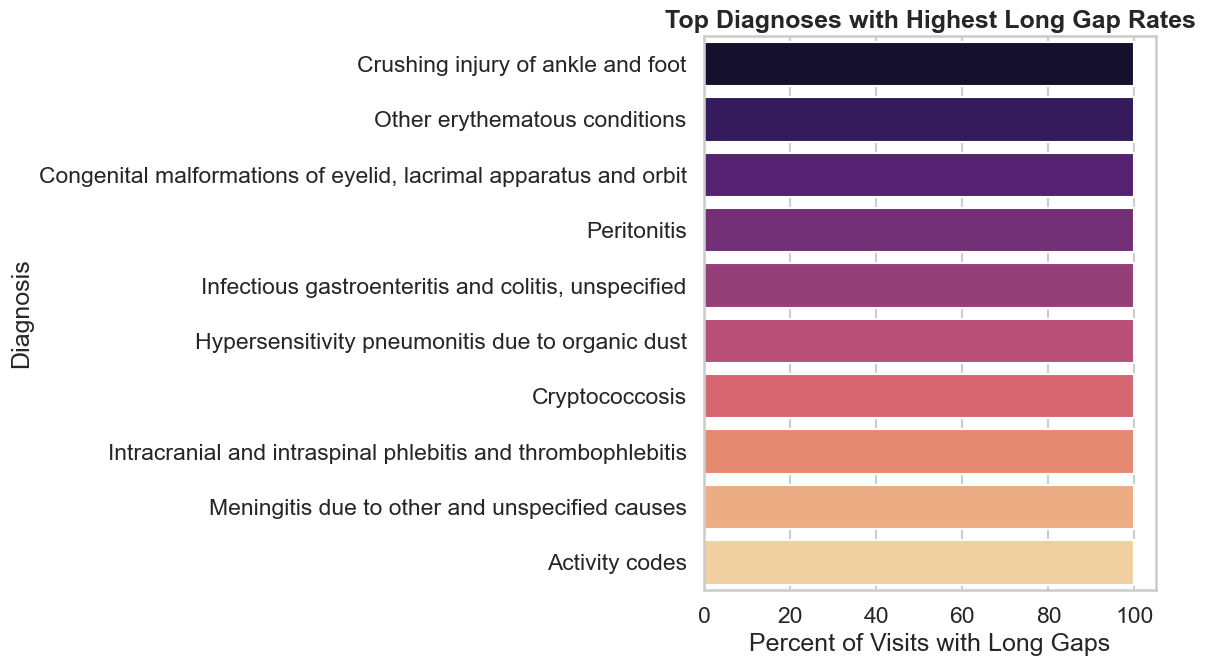

In [27]:
gap_by_condition = df.groupby("GroupName")["LongGap"].mean().sort_values(ascending=False).head(10)

sns.barplot(
    x=gap_by_condition.values * 100,
    y=gap_by_condition.index,
    palette="magma"
)

plt.title("Top Diagnoses with Highest Long Gap Rates", weight='bold')
plt.xlabel("Percent of Visits with Long Gaps")
plt.ylabel("Diagnosis")
plt.tight_layout()
plt.show()

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/1992186615.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


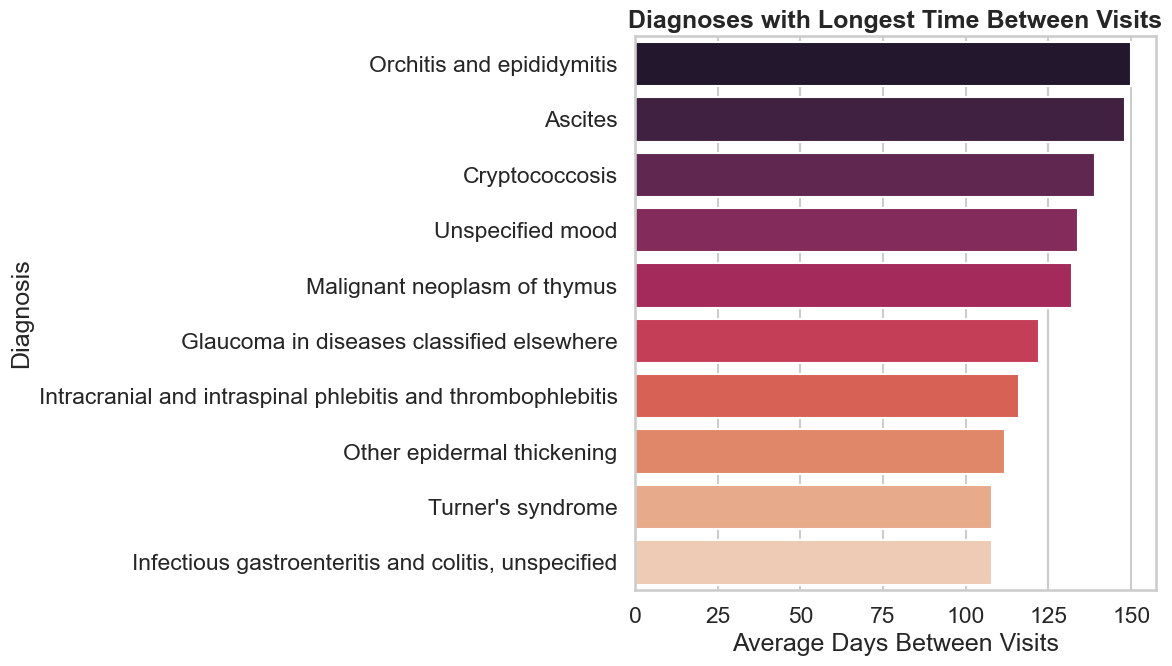

In [28]:
avg_gap_by_condition = df.groupby("GroupName")["TimeGap"].mean().sort_values(ascending=False).head(10)

sns.barplot(
    x=avg_gap_by_condition.values,
    y=avg_gap_by_condition.index,
    palette="rocket"
)

plt.title("Diagnoses with Longest Time Between Visits", weight='bold')
plt.xlabel("Average Days Between Visits")
plt.ylabel("Diagnosis")
plt.tight_layout()
plt.show()

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/4035760183.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


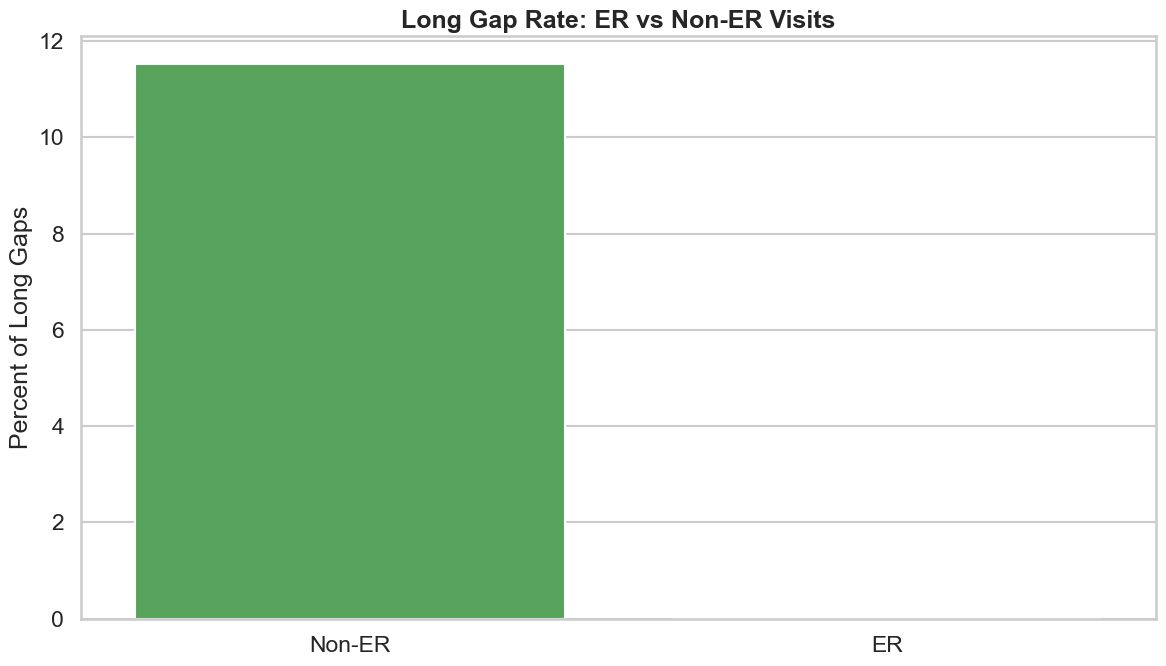

In [29]:
er_gap = df.groupby("IsEdVisit")["LongGap"].mean()

sns.barplot(
    x=["Non-ER", "ER"],
    y=er_gap.values * 100,
    palette=["#4CAF50", "#E74C3C"]
)

plt.title("Long Gap Rate: ER vs Non-ER Visits", weight='bold')
plt.ylabel("Percent of Long Gaps")
plt.tight_layout()
plt.show()

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/625162695.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


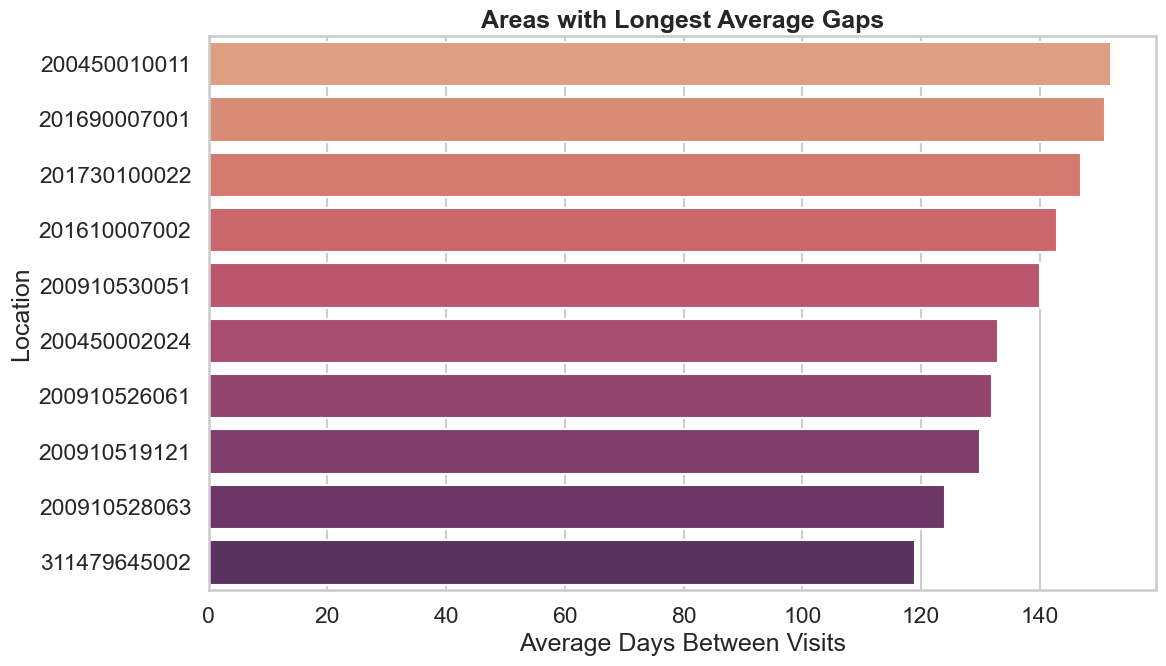

In [30]:
location_gap = df.groupby("CensusBlockGroupFipsCode")["TimeGap"].mean().sort_values(ascending=False).head(10)

sns.barplot(
    x=location_gap.values,
    y=location_gap.index,
    palette="flare"
)

plt.title("Areas with Longest Average Gaps", weight='bold')
plt.xlabel("Average Days Between Visits")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/946798466.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


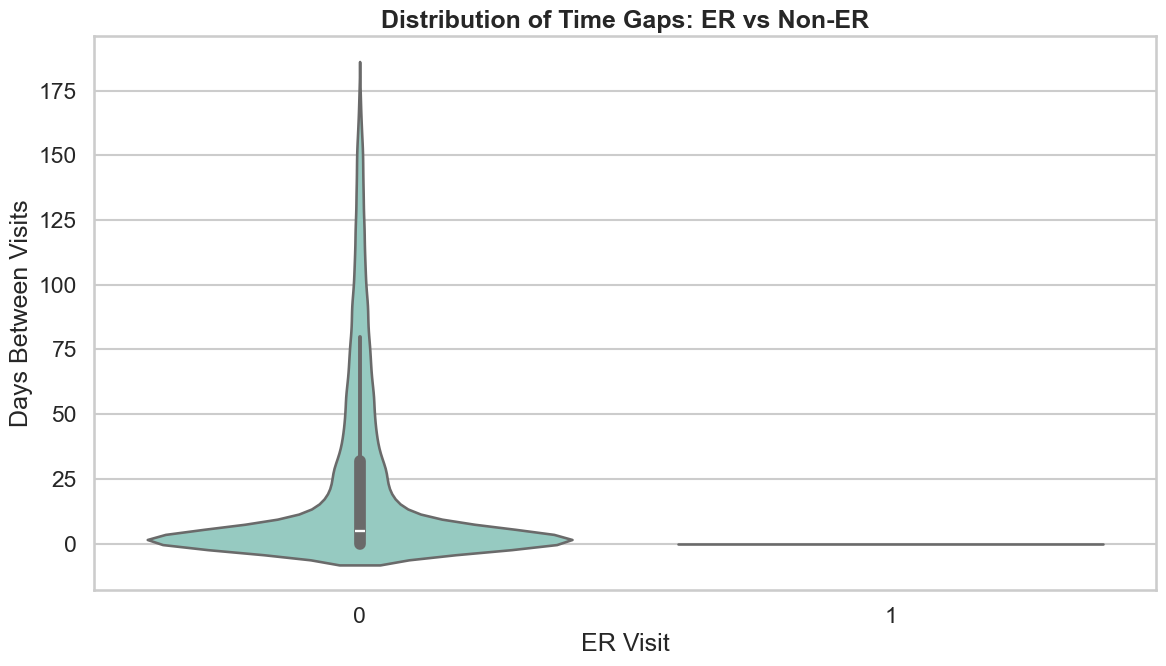

In [31]:
sns.violinplot(
    x="IsEdVisit",
    y="TimeGap",
    data=df,
    palette="Set3"
)

plt.title("Distribution of Time Gaps: ER vs Non-ER", weight='bold')
plt.xlabel("ER Visit")
plt.ylabel("Days Between Visits")
plt.tight_layout()
plt.show()

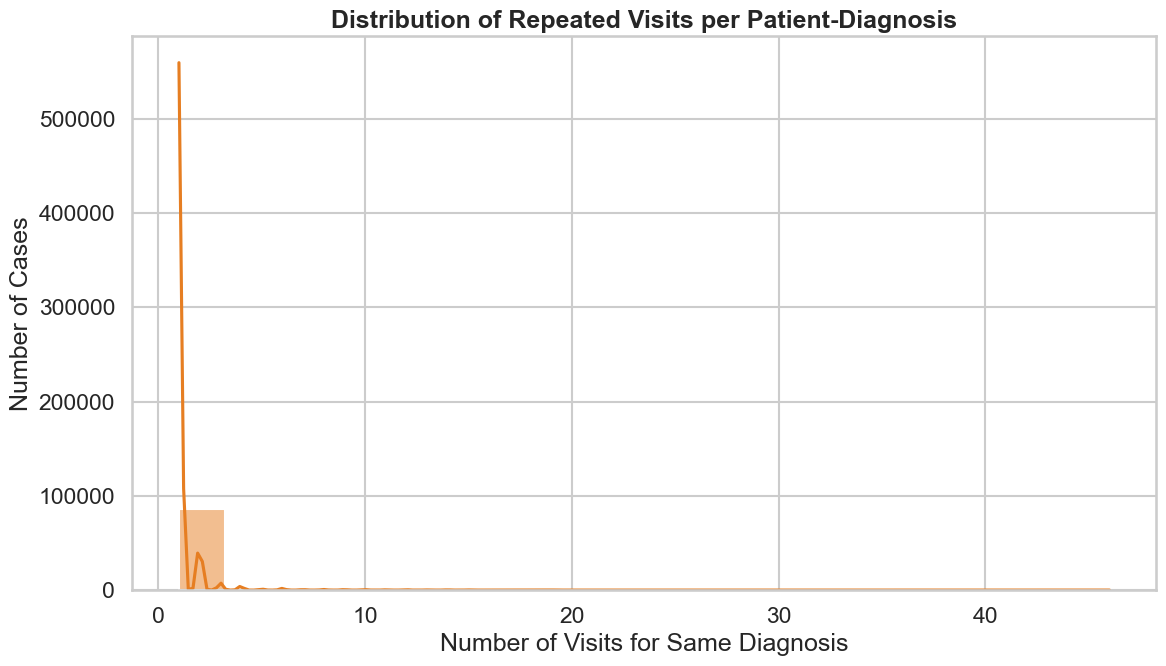

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/1819552897.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


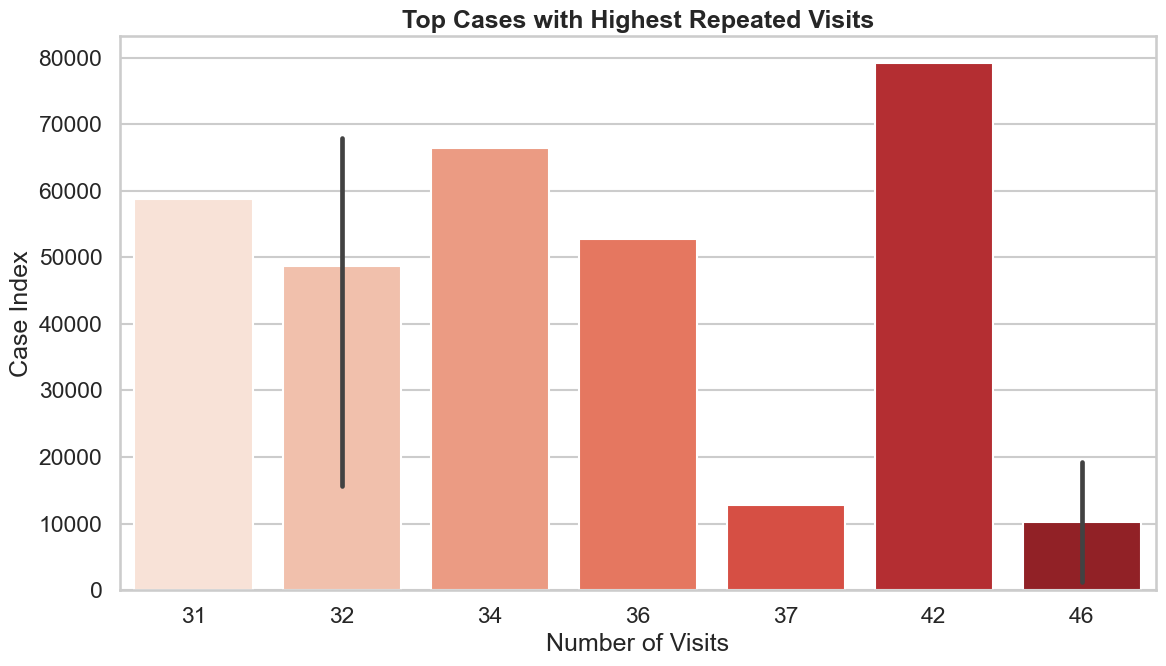

In [ ]:
repeat_tests = df.groupby(
    ["PatientDurableKey", "PrimaryDiagnosisKey"]
).size().reset_index(name="VisitCount")

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    repeat_tests["VisitCount"],
    bins=20,
    kde=True,
    color="#E67E22"
)

plt.title("Distribution of Repeated Visits per Patient-Diagnosis", weight='bold')
plt.xlabel("Number of Visits for Same Diagnosis")
plt.ylabel("Number of Cases")

plt.tight_layout()
plt.show()

top_repeats = repeat_tests.sort_values(by="VisitCount", ascending=False).head(10)

sns.barplot(
    x=top_repeats["VisitCount"],
    y=top_repeats.index,
    palette="Reds"
)

plt.title("Top Cases with Highest Repeated Visits", weight='bold')
plt.xlabel("Number of Visits")
plt.ylabel("Case Index")

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pearsonr

corr_data = df[["VisitsPerPatient", "TimeGap"]].dropna()

corr, p_value = pearsonr(corr_data["VisitsPerPatient"], corr_data["TimeGap"])

print("\n=== CORRELATION TEST ===")
print("Correlation:", round(corr, 3))
print("p-value:", p_value)


=== CORRELATION TEST ===
Correlation: -0.269
p-value: 0.0


In [ ]:
from scipy.stats import ttest_ind

df_valid = df[df["TimeGap"].notna()]

visits_per_patient = df_valid.groupby("PatientDurableKey").size()
df_valid["VisitsPerPatient"] = df_valid["PatientDurableKey"].map(visits_per_patient)

median_visits = df_valid["VisitsPerPatient"].median()

df_valid["HighVisits"] = df_valid["VisitsPerPatient"] > median_visits

high = df_valid[df_valid["HighVisits"] == True]["TimeGap"]
low = df_valid[df_valid["HighVisits"] == False]["TimeGap"]

print("High count:", len(high))
print("Low count:", len(low))

t_stat, p_value = ttest_ind(high, low, equal_var=False)

print("\n=== HIGH VS LOW VISIT TEST ===")
print("t-stat:", t_stat)
print("p-value:", p_value)

print("High visit mean gap:", high.mean())
print("Low visit mean gap:", low.mean())

High count: 21659
Low count: 26936

=== HIGH VS LOW VISIT TEST ===
t-stat: -75.75960713156178
p-value: 0.0
High visit mean gap: 11.09418717392308
Low visit mean gap: 33.11716661716662


/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/1843917506.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid["VisitsPerPatient"] = df_valid["PatientDurableKey"].map(visits_per_patient)
/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/1843917506.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid["HighVisits"] = df_valid["VisitsPerPatient"] > median_visits


In [ ]:
from scipy.stats import f_oneway

top_diag = repeat_tests.merge(
    diagnosis,
    left_on="PrimaryDiagnosisKey",
    right_on="DiagnosisKey",
    how="left"
)

top_groups = top_diag["GroupName"].value_counts().head(5).index

groups = [
    top_diag[top_diag["GroupName"] == g]["VisitCount"].dropna()
    for g in top_groups
]

f_stat, p_value = f_oneway(*groups)

print("\n=== ANOVA TEST (REPEATS BY DIAGNOSIS) ===")
print("F-stat:", f_stat)
print("p-value:", p_value)


=== ANOVA TEST (REPEATS BY DIAGNOSIS) ===
F-stat: 7906.178933404733
p-value: 0.0
